In [1]:
# Load the cleaned COMPAS dataset by specifying the path to the file 
# df = pd.read_csv("FILEPATH")

import pandas as pd
df = pd.read_csv("../data/compas_clean.csv")

Saved ../images/audit-file/roc_with_without_race.png


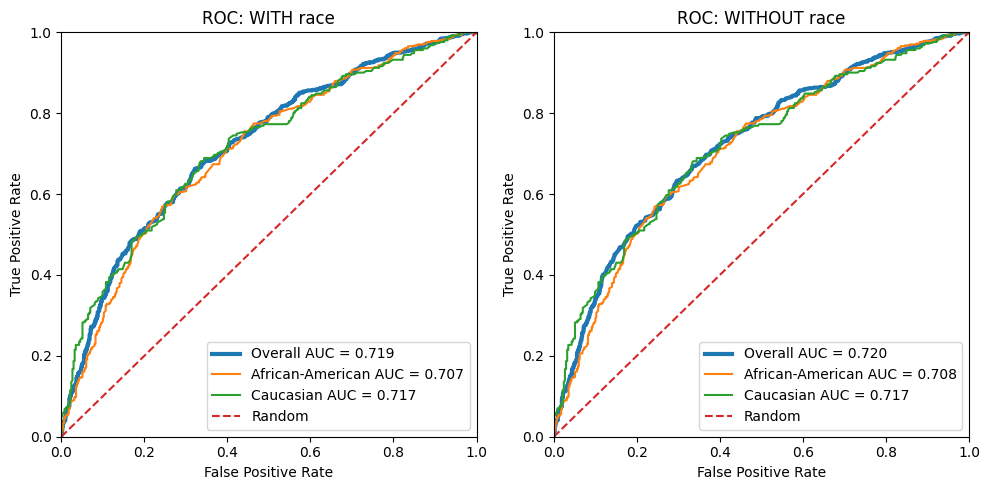

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

FIGURES_DIR = Path("../images/audit-file")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Keep only the two racial groups discussed in the COMPAS controversy
df = df[df["race"].isin(["African-American", "Caucasian"])].copy()

# Target: 1 = reoffended within two years
y = df["two_year_recid"].astype(int)

# Protected attribute used later for fairness analysis
race = df["race"]

# the train/test split is random
train_idx, test_idx = train_test_split(df.index,test_size=0.25,random_state=42, stratify=y)
base_features = ["sex", "age", "priors_count", "c_charge_degree"]

# Compare a model that can use race with one that cannot
model_specs = {"WITH race": base_features + ["race"],
    "WITHOUT race": base_features}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
trained_models = {}

for ax, (title, features) in zip(axes, model_specs.items()):
    X = df[features]

    # Separate categorical and numerical features
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = [c for c in features if c not in cat_cols]

    model = Pipeline(
        [("prep", ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)])),
        ("clf", LogisticRegression(max_iter=1000))] 
    )

    # Train model
    model.fit(X.loc[train_idx], y.loc[train_idx])

    # True outcomes and race information for the test set
    # (used later to evaluate fairness across groups)

    y_test = y.loc[test_idx]
    race_test = race.loc[test_idx]

    # Predicted probability of recidivism
    y_score = model.predict_proba(X.loc[test_idx])[:, 1]

    # Convert probabilities into binary predictions
    y_pred = (y_score >= 0.5).astype(int)

    trained_models[title] = {
        "model": model,
        "features": features,
        "y_test": y_test,
        "race_test": race_test,
        "y_score": y_score,
        "y_pred": y_pred,}

    # Overall ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, linewidth=3, label=f"Overall AUC = {auc(fpr, tpr):.3f}")

    # ROC curves for each racial group
    for group in sorted(race_test.unique()):
        mask = race_test == group
        fpr_g, tpr_g, _ = roc_curve(y_test[mask], y_score[mask])
        ax.plot(fpr_g, tpr_g, label=f"{group} AUC = {auc(fpr_g, tpr_g):.3f}")

    # Random guessing baseline
    ax.plot([0, 1], [0, 1], "--", label="Random")

    ax.set_title(f"ROC: {title}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
roc_path = FIGURES_DIR / "roc_with_without_race.png"
fig.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Saved {roc_path}")
plt.show()

# Keep the model without race for the fairness audit below
audit = trained_models["WITHOUT race"]


### Fairness mitigation with fairlearn

We compare three standard mitigation strategies on top of logistic regression:

| Stage | Idea | fairlearn tool |
|-------|------|----------------|
| **Pre-processing** | Remove correlation between features and the sensitive attribute | `CorrelationRemover` |
| **In-processing** | Train with a fairness constraint during learning | `ExponentiatedGradient` + `EqualizedOdds` |
| **Post-processing** | Adjust thresholds per group after training | `ThresholdOptimizer` |

Conceptually, the models look like this:

```python
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pre_model = Pipeline([
    ("corr_remover", CorrelationRemover(sensitive_feature_ids=["race"], alpha=1.0)),
    ("clf", LogisticRegression(max_iter=1000))
])

in_model = ExponentiatedGradient(
    LogisticRegression(max_iter=1000),
    constraints=EqualizedOdds()
)

post_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000),
    constraints="equalized_odds",
    prefit=False
)
```

The next cell adapts this to our COMPAS data (numeric encoding, preprocessing, and `sensitive_features` where needed) and reports performance metrics.


,method,group,accuracy,false alarms (false positives),false negatives,true positives,true negatives
0,baseline,Overall,0.660598,0.283800,0.403068,0.596932,0.716200
1,baseline,African-American,0.650273,0.380846,0.319742,0.680258,0.619154
2,baseline,Caucasian,0.675762,0.166667,0.557769,0.442231,0.833333
3,CorrelationRemover,Overall,0.659948,0.271620,0.418410,0.581590,0.728380
4,CorrelationRemover,African-American,0.656831,0.222717,0.459227,0.540773,0.777283
5,CorrelationRemover,Caucasian,0.664526,0.330645,0.342629,0.657371,0.669355
6,ExponentiatedGradient,Overall,0.544213,0.159562,0.794979,0.205021,0.840438
7,ExponentiatedGradient,African-American,0.516940,0.169265,0.785408,0.214592,0.830735
8,ExponentiatedGradient,Caucasian,0.584270,0.147849,0.812749,0.187251,0.852151
9,ThresholdOptimizer,Overall,0.641743,0.151035,0.595537,0.404463,0.848965


Saved ../images/audit-file/table_performance.png


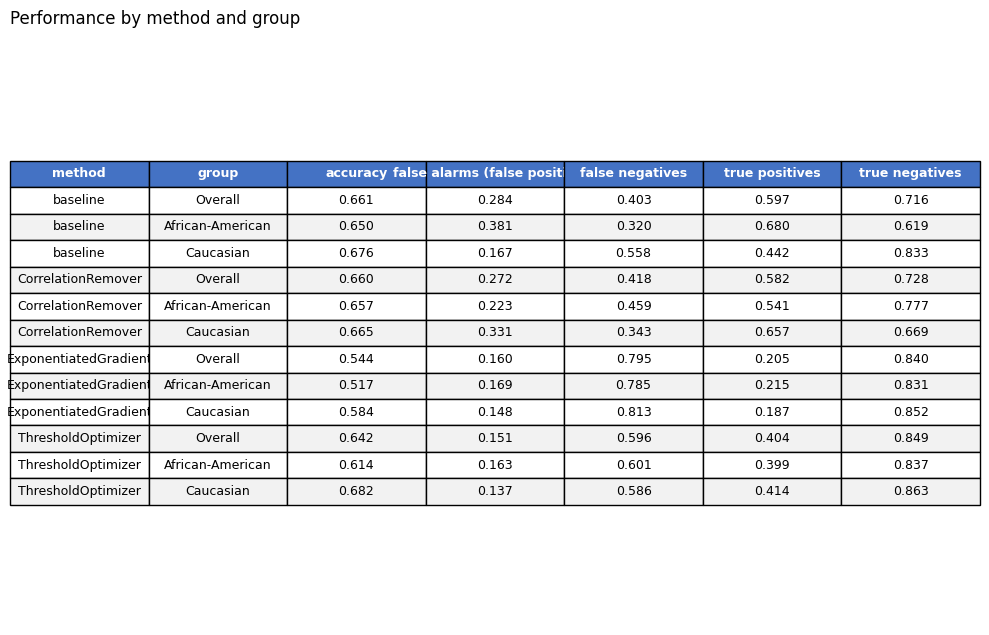

,method,accuracy,equalized odds difference,fairness (1 - EOD)
0,baseline,0.660598,0.238026,0.761974
1,CorrelationRemover,0.659948,0.116598,0.883402
2,ExponentiatedGradient,0.544213,0.027341,0.972659
3,ThresholdOptimizer,0.641743,0.025487,0.974513


Saved ../images/audit-file/table_fairness_summary.png


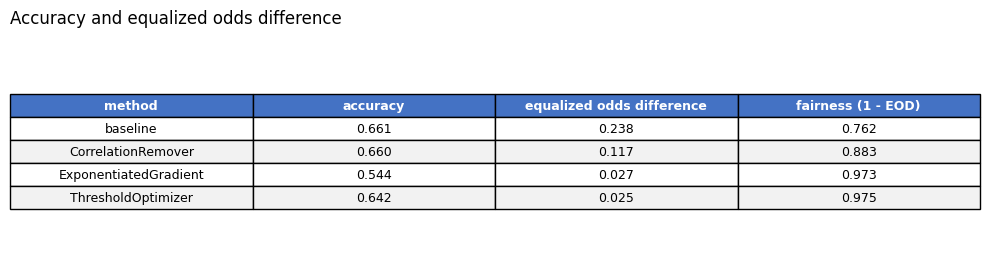

Saved ../images/audit-file/confusion_matrices_overall.png


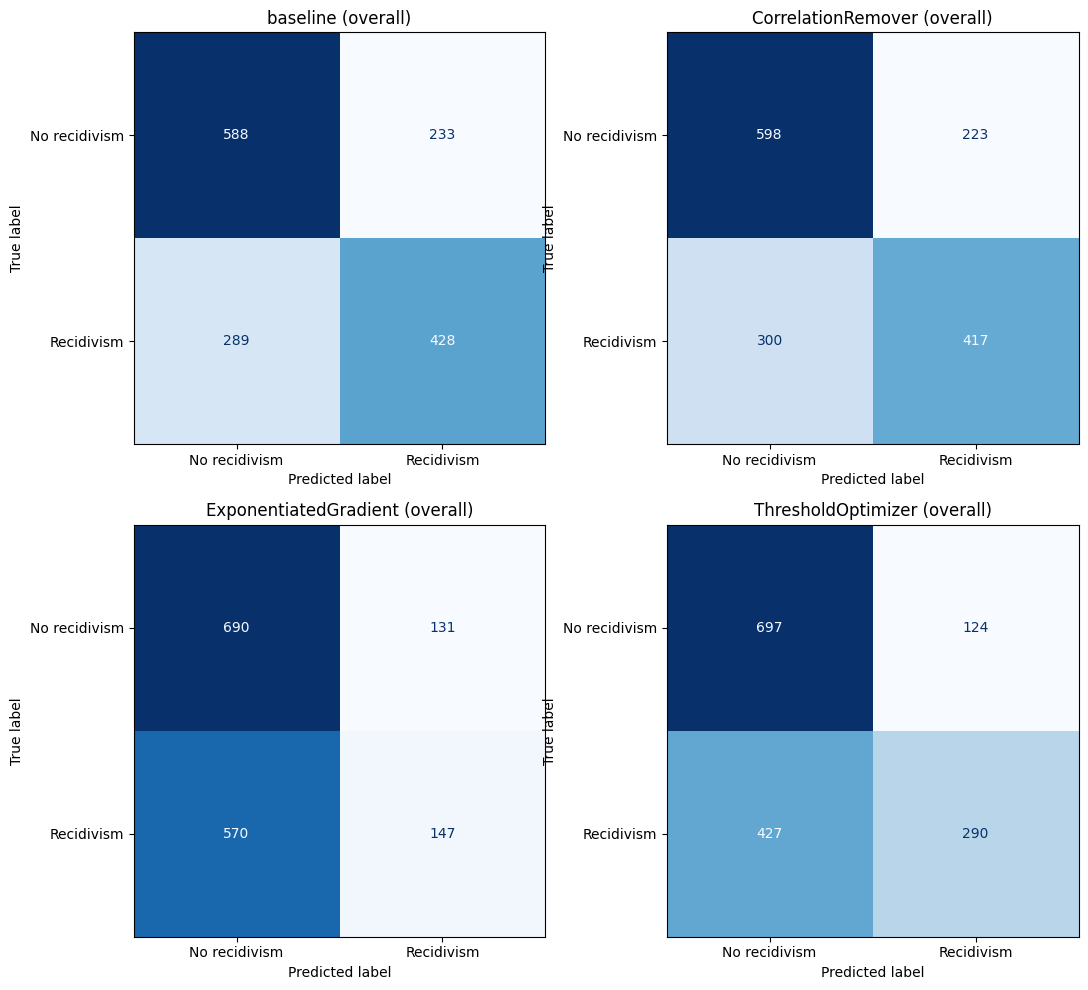

Saved ../images/audit-file/confusion_matrices_by_race.png


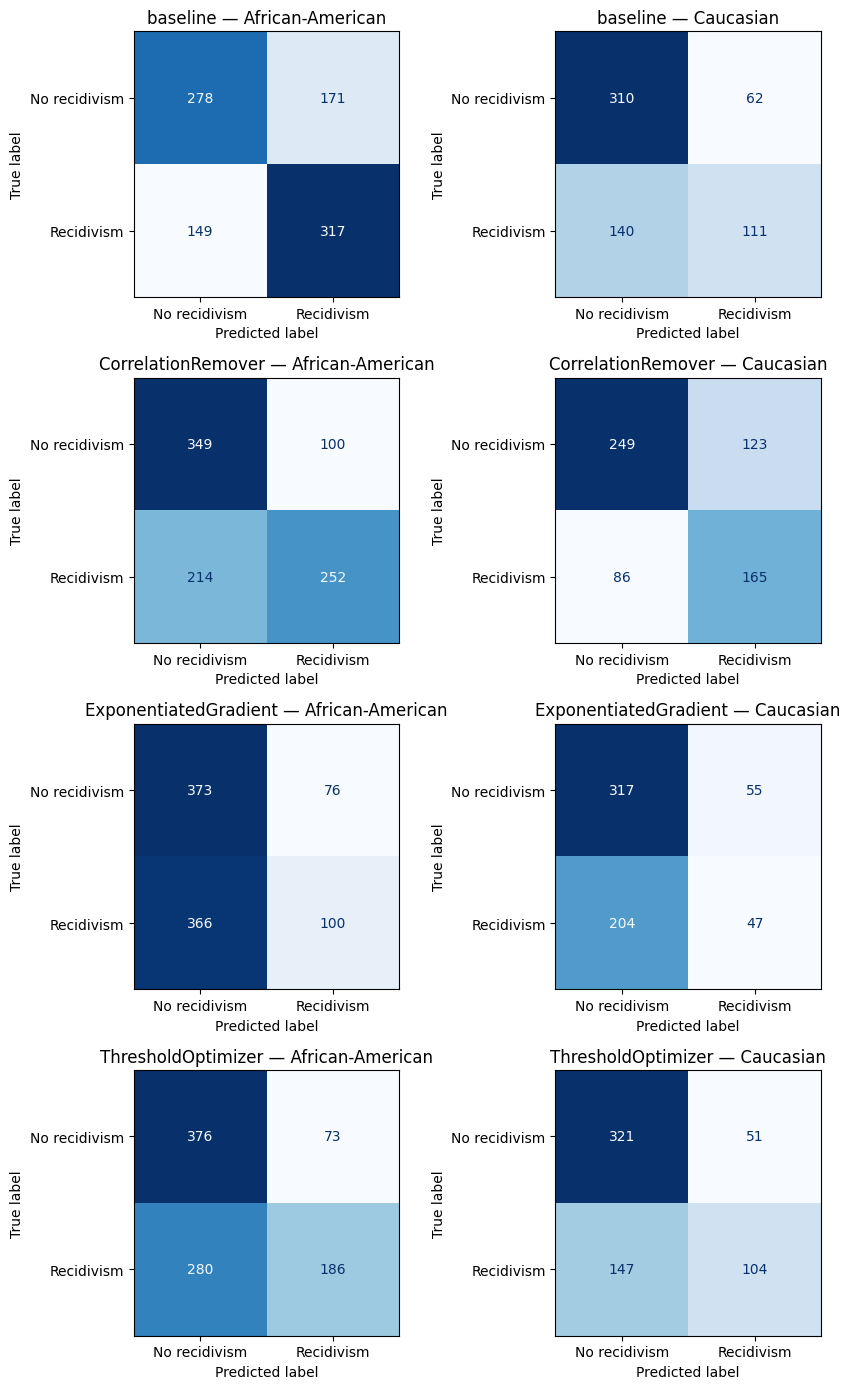

Saved ../images/audit-file/bars_accuracy.png


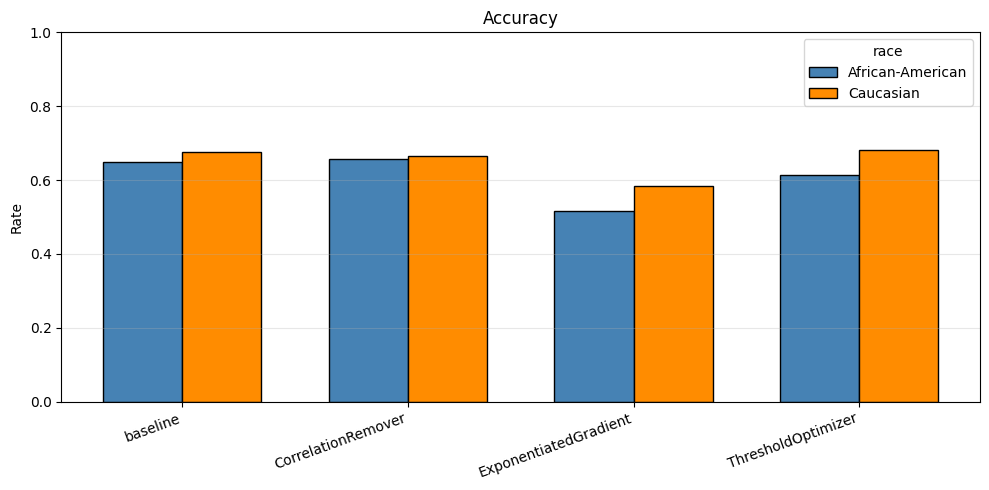

Saved ../images/audit-file/diff_accuracy.png


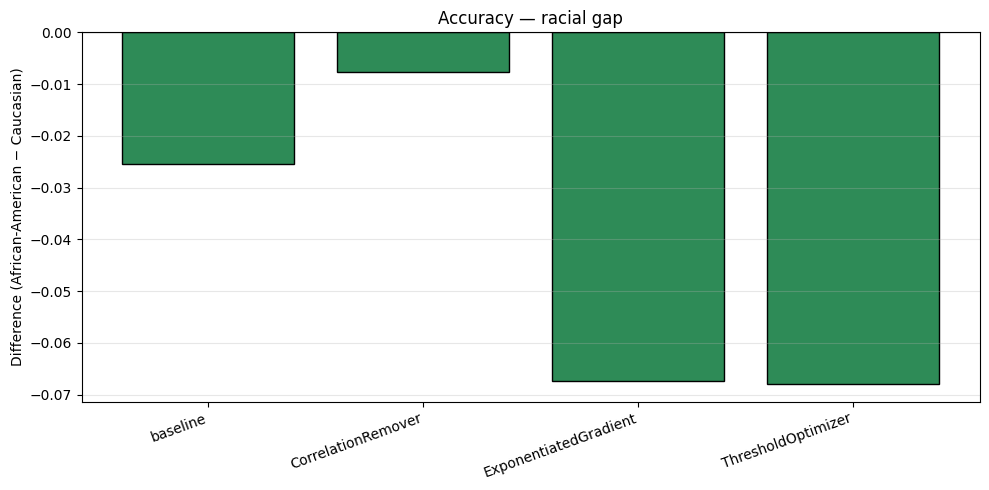

Saved ../images/audit-file/bars_false_alarms.png


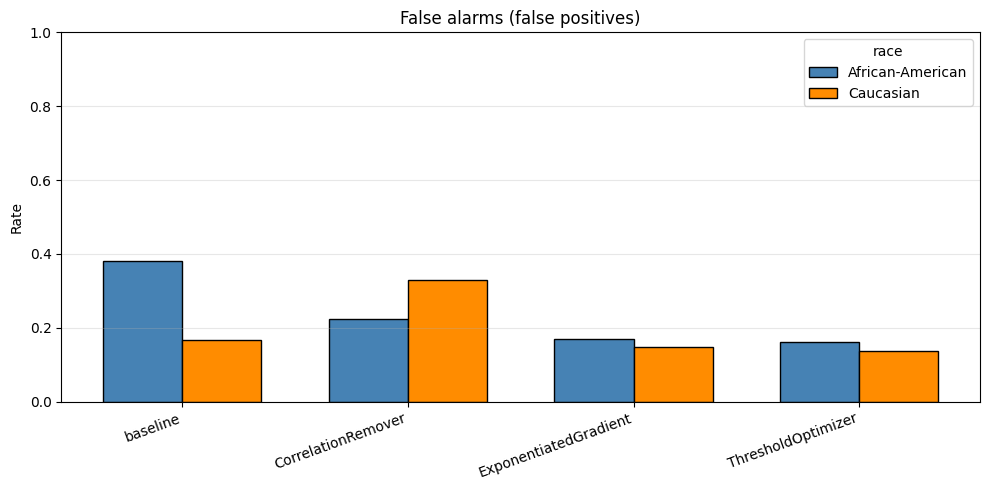

Saved ../images/audit-file/diff_false_alarms.png


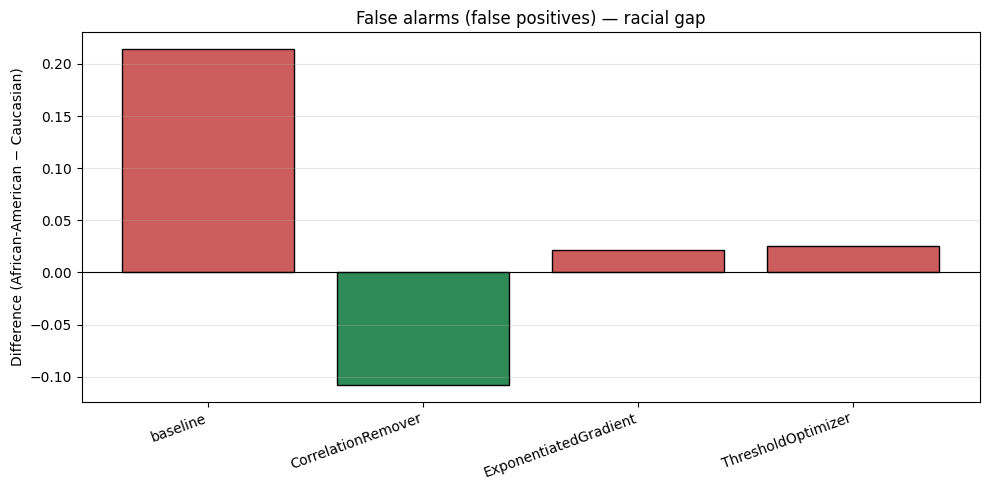

Saved ../images/audit-file/bars_false_negatives.png


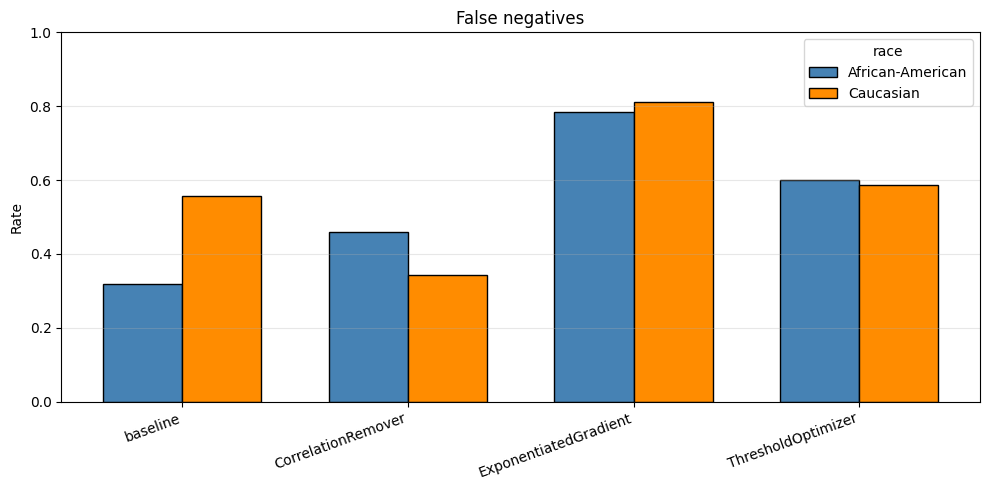

Saved ../images/audit-file/diff_false_negatives.png


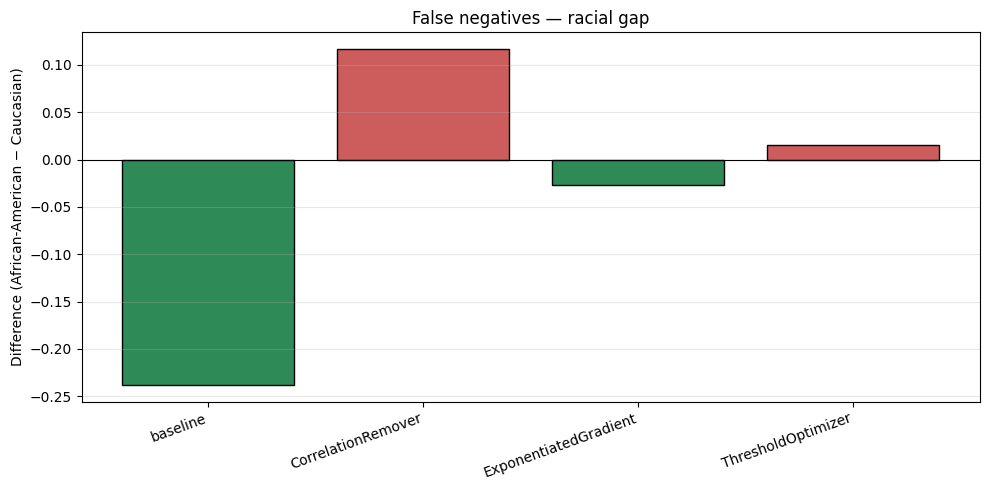

Saved ../images/audit-file/bars_true_positives.png


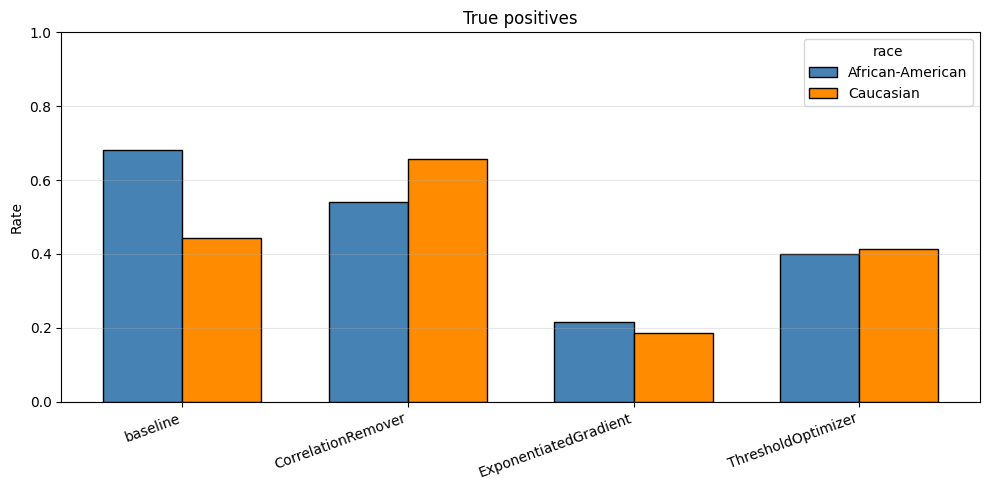

Saved ../images/audit-file/diff_true_positives.png


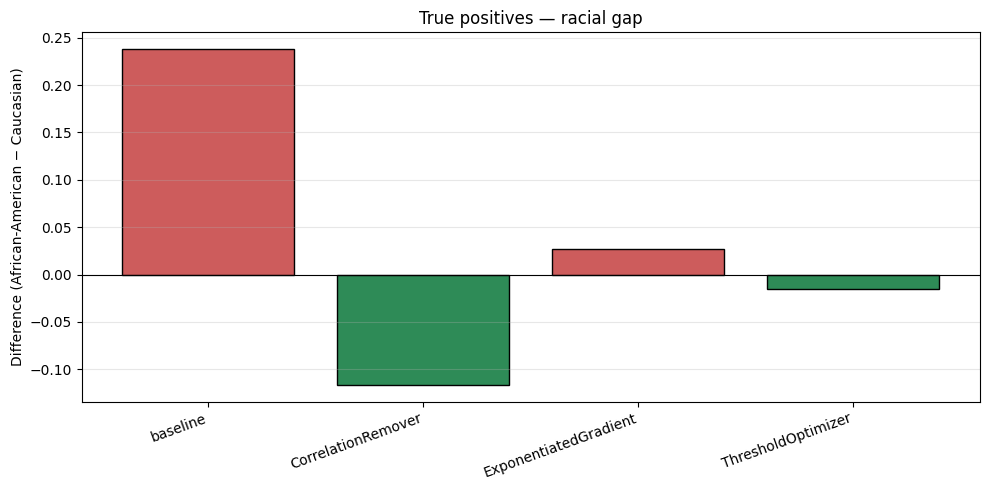

Saved ../images/audit-file/bars_true_negatives.png


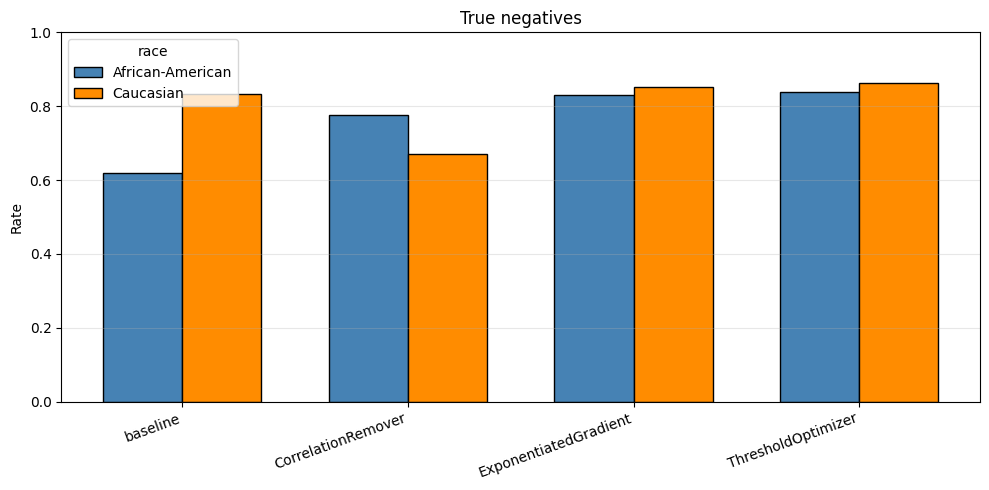

Saved ../images/audit-file/diff_true_negatives.png


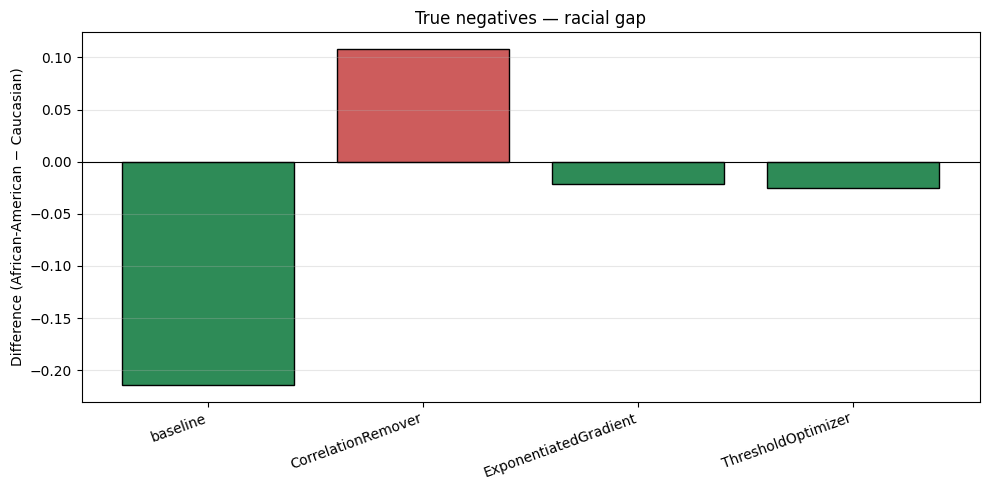

Saved ../images/audit-file/bars_equalized_odds_difference.png


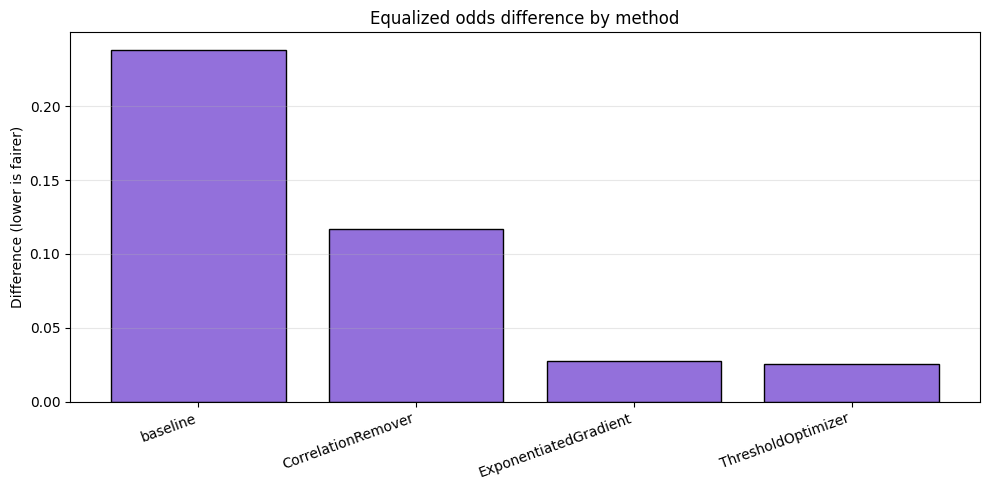

Saved ../images/audit-file/error_rate_gaps.png
Saved 1-mitigation/error_rate_gaps.png


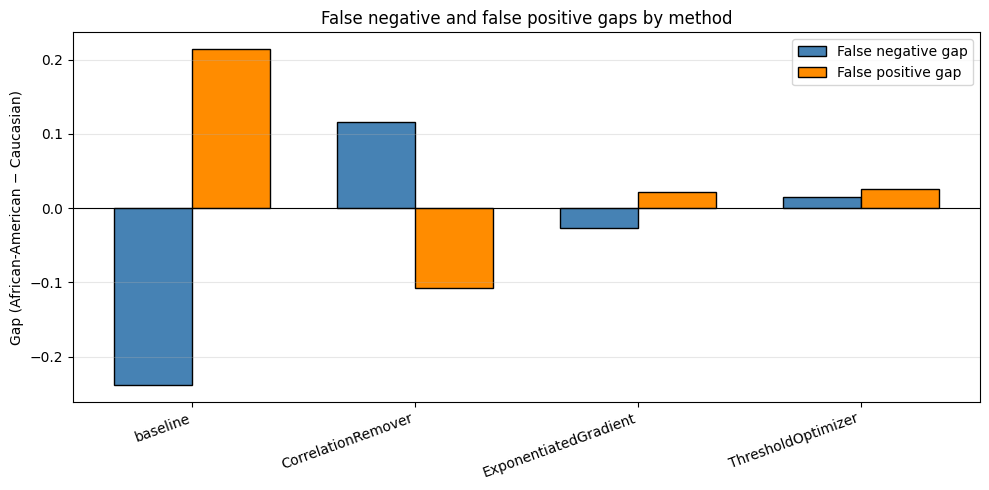

Saved ../images/audit-file/accuracy_vs_equalized_odds.png


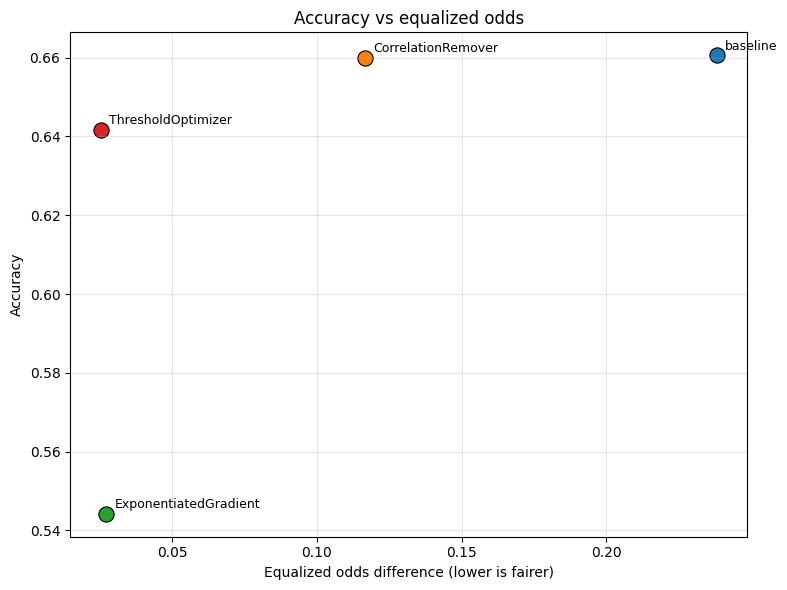

Saved ../images/audit-file/accuracy_vs_fairness_1minus_eod.png


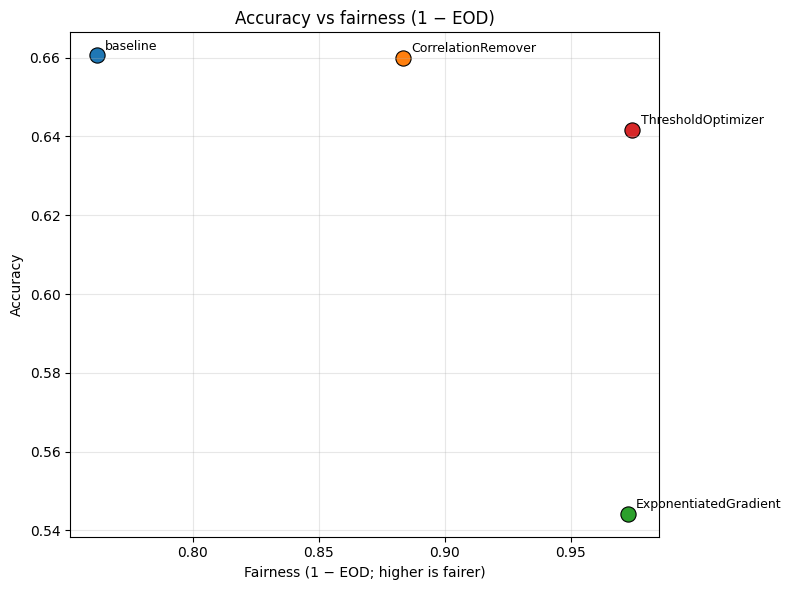

Saved ../images/audit-file/baseline_mitigation_differences.png


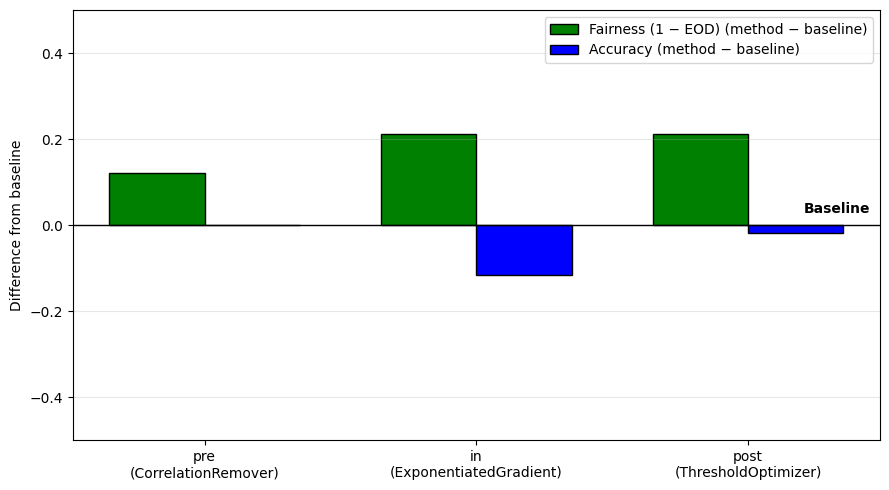

Saved ../images/audit-file/roc_all_mitigation_models.png


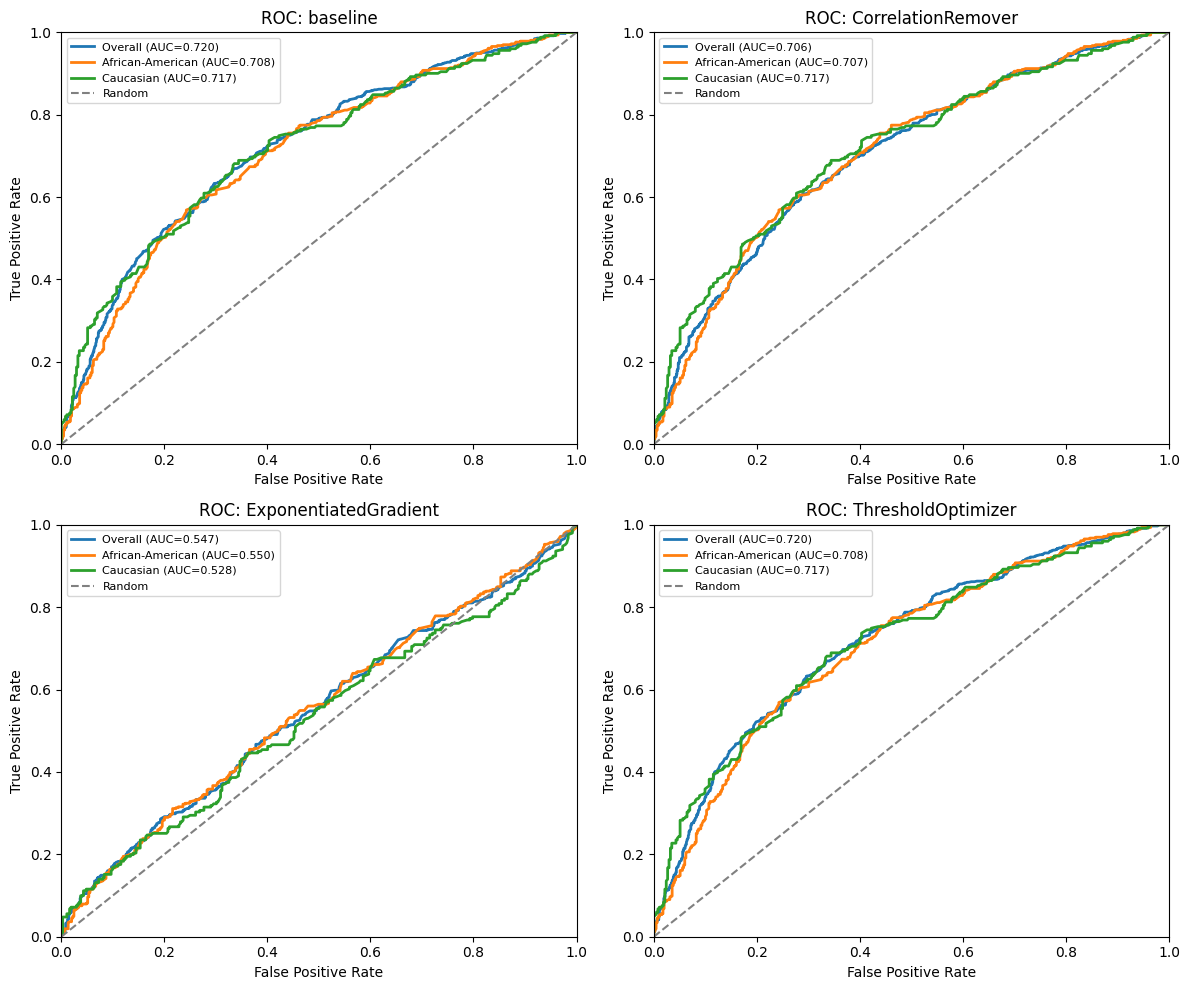

,before,after
sex,-0.076079,4.750386e-16
age,0.208190,-1.095855e-15
priors_count,-0.177603,8.209622e-16
c_charge_degree,-0.080866,4.693899e-16


Saved ../images/audit-file/table_feature_race_correlation.png


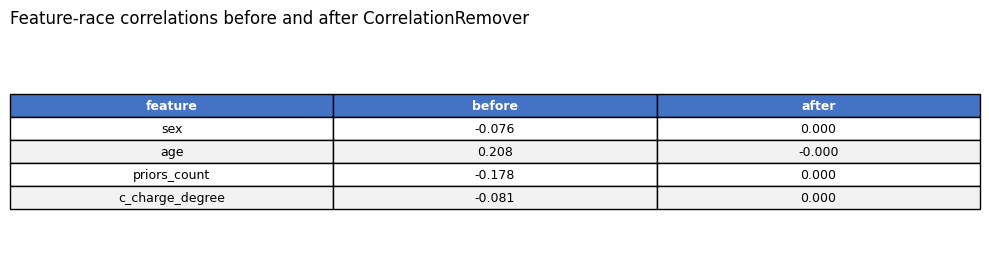

Saved ../images/audit-file/feature_race_correlation_before_after.png


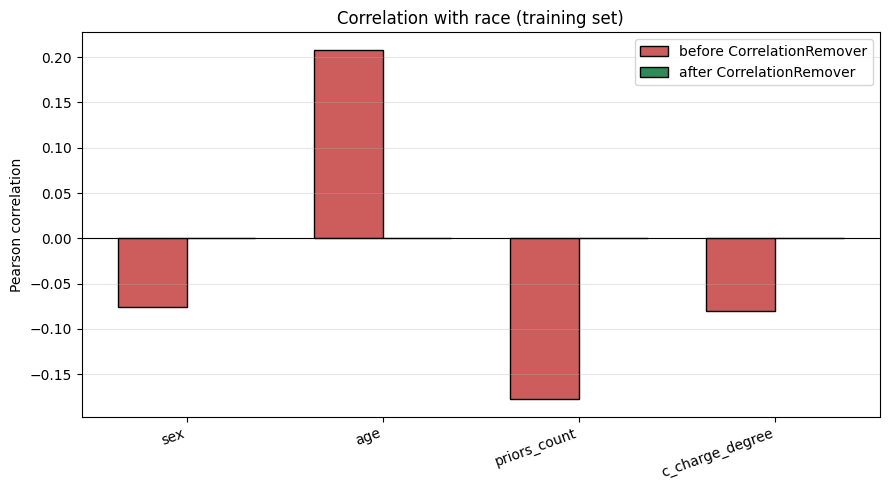

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from fairlearn.metrics import equalized_odds_difference
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

FIGURES_DIR = Path("../images/audit-file")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PRIVILEGED = "Caucasian"
UNPRIVILEGED = "African-American"
METHOD_ORDER = [
    "baseline",
    "CorrelationRemover",
    "ExponentiatedGradient",
    "ThresholdOptimizer",
]

features = audit["features"]
features_with_race = features + ["race"]

X_base_train = df[features].loc[train_idx]
X_base_test = df[features].loc[test_idx]
X_race_train = df[features_with_race].loc[train_idx]
X_race_test = df[features_with_race].loc[test_idx]

y_train = y.loc[train_idx]
y_test = audit["y_test"]
race_train = race.loc[train_idx]
race_test = audit["race_test"]

cat_cols = df[features].select_dtypes(include="object").columns.tolist()
num_cols = [c for c in features if c not in cat_cols]
feature_names = ["sex", "age", "priors_count", "c_charge_degree"]

prep = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)


def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved {path}")


def save_table_figure(df, filename, title=None, float_fmt="{:.3f}"):
    table_df = df.copy()
    for col in table_df.select_dtypes(include="number").columns:
        table_df[col] = table_df[col].map(lambda v: float_fmt.format(v) if pd.notna(v) else "")

    n_rows, n_cols = table_df.shape
    fig_w = max(10, 1.2 * n_cols)
    fig_h = max(2.5, 0.45 * (n_rows + 1) + (0.6 if title else 0))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, pad=12, loc="left")

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.35)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#4472C4")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#F2F2F2")

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def encode_for_correlation_remover(X):
    out = X[features].copy()
    out["sex"] = (out["sex"] == "Male").astype(int)
    out["c_charge_degree"] = (out["c_charge_degree"] == "F").astype(int)
    out["race"] = (X["race"] == PRIVILEGED).astype(int)
    return out[feature_names + ["race"]]


def exponentiated_gradient_scores(model, X):
    scores = np.zeros(len(X))
    for weight, predictor in zip(model.weights_, model.predictors_):
        scores += weight * predictor.predict_proba(X)[:, 1]
    return scores


def performance_table(y_true, y_pred, groups, method):
    rows = []
    masks = [("Overall", np.ones(len(y_true), dtype=bool))]
    for group in sorted(groups.unique()):
        masks.append((group, (groups == group).to_numpy()))

    for group_name, mask in masks:
        yt = y_true[mask]
        yp = y_pred[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        rows.append(
            {
                "method": method,
                "group": group_name,
                "accuracy": accuracy_score(yt, yp),
                "false alarms (false positives)": fp / (fp + tn) if (fp + tn) else np.nan,
                "false negatives": fn / (fn + tp) if (fn + tp) else np.nan,
                "true positives": tp / (tp + fn) if (tp + fn) else np.nan,
                "true negatives": tn / (tn + fp) if (tn + fp) else np.nan,
            }
        )
    return rows


def plot_method_bars(summary_df, metric, title, filename, ylabel="Value"):
    values = [summary_df.loc[summary_df["method"] == m, metric].iloc[0] for m in METHOD_ORDER]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(METHOD_ORDER))
    ax.bar(x, values, color="mediumpurple", edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_accuracy_vs_fairness(summary_df, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in summary_df.iterrows():
        ax.scatter(
            row["equalized odds difference"],
            row["accuracy"],
            s=120,
            edgecolor="black",
            linewidth=0.8,
        )
        ax.annotate(
            row["method"],
            (row["equalized odds difference"], row["accuracy"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )
    ax.set_xlabel("Equalized odds difference (lower is fairer)")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs equalized odds")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_accuracy_vs_fairness_1minus_eod(summary_df, filename):
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in summary_df.iterrows():
        fairness = row["fairness (1 - EOD)"]
        ax.scatter(
            fairness,
            row["accuracy"],
            s=120,
            edgecolor="black",
            linewidth=0.8,
        )
        ax.annotate(
            row["method"],
            (fairness, row["accuracy"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )
    ax.set_xlabel("Fairness (1 − EOD; higher is fairer)")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs fairness (1 − EOD)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


MITIGATION_METHODS = {
    "pre": "CorrelationRemover",
    "in": "ExponentiatedGradient",
    "post": "ThresholdOptimizer",
}


def plot_baseline_differences(summary_df, filename):
    """Bar chart of mitigation-method deltas relative to baseline."""
    baseline = summary_df.loc[summary_df["method"] == "baseline"].iloc[0]
    baseline_fairness = baseline["fairness (1 - EOD)"]
    baseline_acc = baseline["accuracy"]

    labels = list(MITIGATION_METHODS.keys())
    methods = [MITIGATION_METHODS[label] for label in labels]

    fairness_diffs = [
        summary_df.loc[summary_df["method"] == method, "fairness (1 - EOD)"].iloc[0]
        - baseline_fairness
        for method in methods
    ]
    acc_diffs = [
        summary_df.loc[summary_df["method"] == method, "accuracy"].iloc[0] - baseline_acc
        for method in methods
    ]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(
        x - width / 2,
        fairness_diffs,
        width,
        label="Fairness (1 − EOD) (method − baseline)",
        color="green",
        edgecolor="black",
    )
    ax.bar(
        x + width / 2,
        acc_diffs,
        width,
        label="Accuracy (method − baseline)",
        color="blue",
        edgecolor="black",
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.text(
        x[-1] + 0.45,
        0.02,
        "Baseline",
        ha="right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_ylabel("Difference from baseline")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{label}\n({MITIGATION_METHODS[label]})" for label in labels]
    )
    ax.set_ylim(-0.5,0.5)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def _race_values(performance_df, metric, method):
    race_subset = performance_df[performance_df["group"].isin([UNPRIVILEGED, PRIVILEGED])]
    aa = race_subset.loc[
        (race_subset["method"] == method) & (race_subset["group"] == UNPRIVILEGED),
        metric,
    ].iloc[0]
    cauc = race_subset.loc[
        (race_subset["method"] == method) & (race_subset["group"] == PRIVILEGED),
        metric,
    ].iloc[0]
    return aa, cauc


def plot_grouped_bars(performance_df, metric, title, filename):
    aa_vals, cauc_vals = [], []
    for method in METHOD_ORDER:
        aa, cauc = _race_values(performance_df, metric, method)
        aa_vals.append(aa)
        cauc_vals.append(cauc)

    x = np.arange(len(METHOD_ORDER))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, aa_vals, width, label=UNPRIVILEGED, color="steelblue", edgecolor="black")
    ax.bar(x + width / 2, cauc_vals, width, label=PRIVILEGED, color="darkorange", edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel("Rate")
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(title="race")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_grouped_bar_differences(performance_df, metric, title, filename):
    diffs = []
    for method in METHOD_ORDER:
        aa, cauc = _race_values(performance_df, metric, method)
        diffs.append(aa - cauc)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(METHOD_ORDER))
    colors = ["indianred" if d > 0 else "seagreen" for d in diffs]
    ax.bar(x, diffs, color=colors, edgecolor="black")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{title} — racial gap")
    ax.set_ylabel(f"Difference ({UNPRIVILEGED} − {PRIVILEGED})")
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()




def plot_fn_fp_gaps(performance_df, filename, extra_dir=None):
    """Compare false negative and false positive racial gaps across methods."""
    fn_gaps, fp_gaps = [], []
    for method in METHOD_ORDER:
        aa_fn, cauc_fn = _race_values(performance_df, "false negatives", method)
        aa_fp, cauc_fp = _race_values(
            performance_df, "false alarms (false positives)", method
        )
        fn_gaps.append(aa_fn - cauc_fn)
        fp_gaps.append(aa_fp - cauc_fp)

    x = np.arange(len(METHOD_ORDER))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        x - width / 2,
        fn_gaps,
        width,
        label="False negative gap",
        color="steelblue",
        edgecolor="black",
    )
    ax.bar(
        x + width / 2,
        fp_gaps,
        width,
        label="False positive gap",
        color="darkorange",
        edgecolor="black",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("False negative and false positive gaps by method")
    ax.set_ylabel(f"Gap ({UNPRIVILEGED} − {PRIVILEGED})")
    ax.set_xticks(x)
    ax.set_xticklabels(METHOD_ORDER, rotation=20, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, filename)
    if extra_dir is not None:
        extra_path = extra_dir / filename
        fig.savefig(extra_path, dpi=150, bbox_inches="tight")
        print(f"Saved {extra_path}")
    plt.show()


def plot_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No recidivism", "Recidivism"],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)


def plot_confusion_matrices(models, y_true, groups, filename_overall, filename_by_race):
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    for ax, (name, outputs) in zip(axes.ravel(), models.items()):
        plot_confusion_matrix(ax, y_true, outputs["pred"], f"{name} (overall)")
    plt.tight_layout()
    save_figure(fig, filename_overall)
    plt.show()

    fig, axes = plt.subplots(len(METHOD_ORDER), 2, figsize=(9, 14))
    for row, name in enumerate(METHOD_ORDER):
        outputs = models[name]
        for col, group in enumerate([UNPRIVILEGED, PRIVILEGED]):
            mask = groups == group
            plot_confusion_matrix(
                axes[row, col],
                y_true[mask],
                outputs["pred"][mask],
                f"{name} — {group}",
            )
    plt.tight_layout()
    save_figure(fig, filename_by_race)
    plt.show()


def plot_roc_curves(ax, y_true, y_score, groups, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, linewidth=2, label=f"Overall (AUC={auc(fpr, tpr):.3f})")
    for group in sorted(groups.unique()):
        mask = groups == group
        fpr_g, tpr_g, _ = roc_curve(y_true[mask], y_score[mask])
        ax.plot(fpr_g, tpr_g, linewidth=2, label=f"{group} (AUC={auc(fpr_g, tpr_g):.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Random")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)


# --- Train mitigation models ---
pre_model = Pipeline(
    [
        ("corr_remover", CorrelationRemover(sensitive_feature_ids=["race"], alpha=1.0)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)
X_pre_train = encode_for_correlation_remover(X_race_train)
X_pre_test = encode_for_correlation_remover(X_race_test)
pre_model.fit(X_pre_train, y_train)
pre_pred = pre_model.predict(X_pre_test)
pre_score = pre_model.predict_proba(X_pre_test)[:, 1]

in_model = ExponentiatedGradient(
    LogisticRegression(max_iter=1000),
    constraints=EqualizedOdds(),
)
X_in_train = prep.fit_transform(X_base_train)
X_in_test = prep.transform(X_base_test)
in_model.fit(X_in_train, y_train, sensitive_features=race_train)
in_pred = in_model.predict(X_in_test)
in_score = exponentiated_gradient_scores(in_model, X_in_test)

post_model = ThresholdOptimizer(
    estimator=LogisticRegression(max_iter=1000),
    constraints="equalized_odds",
    prefit=False,
)
post_model.fit(X_in_train, y_train, sensitive_features=race_train)
post_pred = post_model.predict(X_in_test, sensitive_features=race_test)
post_score = post_model.estimator_.predict_proba(X_in_test)[:, 1]

models = {
    "baseline": {"pred": audit["y_pred"], "score": audit["y_score"]},
    "CorrelationRemover": {"pred": pre_pred, "score": pre_score},
    "ExponentiatedGradient": {"pred": in_pred, "score": in_score},
    "ThresholdOptimizer": {"pred": post_pred, "score": post_score},
}

results = []
for method, outputs in models.items():
    results += performance_table(y_test, outputs["pred"], race_test, method)
performance = pd.DataFrame(results)
display(performance)
save_table_figure(performance, "table_performance.png", title="Performance by method and group")

fairness_rows = []
for method, outputs in models.items():
    fairness_rows.append(
        {
            "method": method,
            "accuracy": accuracy_score(y_test, outputs["pred"]),
            "equalized odds difference": equalized_odds_difference(
                y_test, outputs["pred"], sensitive_features=race_test
            ),
        }
    )
fairness_summary = pd.DataFrame(fairness_rows)
fairness_summary["fairness (1 - EOD)"] = (
    1 - fairness_summary["equalized odds difference"]
)
display(fairness_summary)
save_table_figure(
    fairness_summary,
    "table_fairness_summary.png",
    title="Accuracy and equalized odds difference",
)

plot_confusion_matrices(
    models,
    y_test,
    race_test,
    "confusion_matrices_overall.png",
    "confusion_matrices_by_race.png",
)

# --- Bar plots: accuracy and all confusion-matrix rates ---
bar_plot_files = [
    ("accuracy", "Accuracy", "bars_accuracy.png", "diff_accuracy.png"),
    ("false alarms (false positives)", "False alarms (false positives)", "bars_false_alarms.png", "diff_false_alarms.png"),
    ("false negatives", "False negatives", "bars_false_negatives.png", "diff_false_negatives.png"),
    ("true positives", "True positives", "bars_true_positives.png", "diff_true_positives.png"),
    ("true negatives", "True negatives", "bars_true_negatives.png", "diff_true_negatives.png"),
]
for metric, title, bars_file, diff_file in bar_plot_files:
    plot_grouped_bars(performance, metric, title, bars_file)
    plot_grouped_bar_differences(performance, metric, title, diff_file)

plot_method_bars(
    fairness_summary,
    "equalized odds difference",
    "Equalized odds difference by method",
    "bars_equalized_odds_difference.png",
    ylabel="Difference (lower is fairer)",
)

MITIGATION_DIR = Path("1-mitigation")
MITIGATION_DIR.mkdir(parents=True, exist_ok=True)
plot_fn_fp_gaps(
    performance,
    "error_rate_gaps.png",
    extra_dir=MITIGATION_DIR,
)

plot_accuracy_vs_fairness(fairness_summary, "accuracy_vs_equalized_odds.png")
plot_accuracy_vs_fairness_1minus_eod(
    fairness_summary, "accuracy_vs_fairness_1minus_eod.png"
)
plot_baseline_differences(fairness_summary, "baseline_mitigation_differences.png")

# --- ROC curves for all models ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, outputs) in zip(axes.ravel(), models.items()):
    plot_roc_curves(ax, y_test, outputs["score"], race_test, f"ROC: {name}")
plt.tight_layout()
save_figure(fig, "roc_all_mitigation_models.png")
plt.show()

# --- Feature-race correlations before / after CorrelationRemover ---
X_encoded = encode_for_correlation_remover(X_race_train)
race_values = X_encoded["race"]

corr_before = X_encoded[feature_names].corrwith(race_values)

corr_remover = CorrelationRemover(sensitive_feature_ids=["race"], alpha=1.0)
X_transformed = corr_remover.fit_transform(X_encoded)
X_transformed = pd.DataFrame(X_transformed, columns=feature_names, index=X_encoded.index)
corr_after = X_transformed.corrwith(race_values)

corr_comparison = pd.DataFrame({"before": corr_before, "after": corr_after})
display(corr_comparison)
save_table_figure(
    corr_comparison.reset_index(names="feature"),
    "table_feature_race_correlation.png",
    title="Feature-race correlations before and after CorrelationRemover",
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(feature_names))
width = 0.35
ax.bar(x - width / 2, corr_before.values, width, label="before CorrelationRemover", color="indianred", edgecolor="black")
ax.bar(x + width / 2, corr_after.values, width, label="after CorrelationRemover", color="seagreen", edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with race (training set)")
ax.set_ylabel("Pearson correlation")
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_figure(fig, "feature_race_correlation_before_after.png")
plt.show()
